<a href="https://colab.research.google.com/github/VardhanVelamakanni/cifar10-vit/blob/main/ViT_CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install timm torchinfo

In [2]:
import time
import copy
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import timm

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from torchinfo import summary
from tqdm.auto import tqdm

In [3]:
# Config
BATCH_SIZE = 128
NUM_EPOCHS = 10

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

IMAGE_SIZE = 224

MODEL_NAME = "vit_base_patch16_224"

NUM_CLASSES = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
np.random.seed(42)

print("Device:", DEVICE)

Device: cuda


In [4]:
classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMAGE_SIZE, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [6]:
train_dataset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

100%|██████████| 170M/170M [55:55<00:00, 50.8kB/s]


In [23]:

#Data Loaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Training Images : {len(train_dataset)}")
print(f"Testing Images  : {len(test_dataset)}")

Training Images : 50000
Testing Images  : 10000


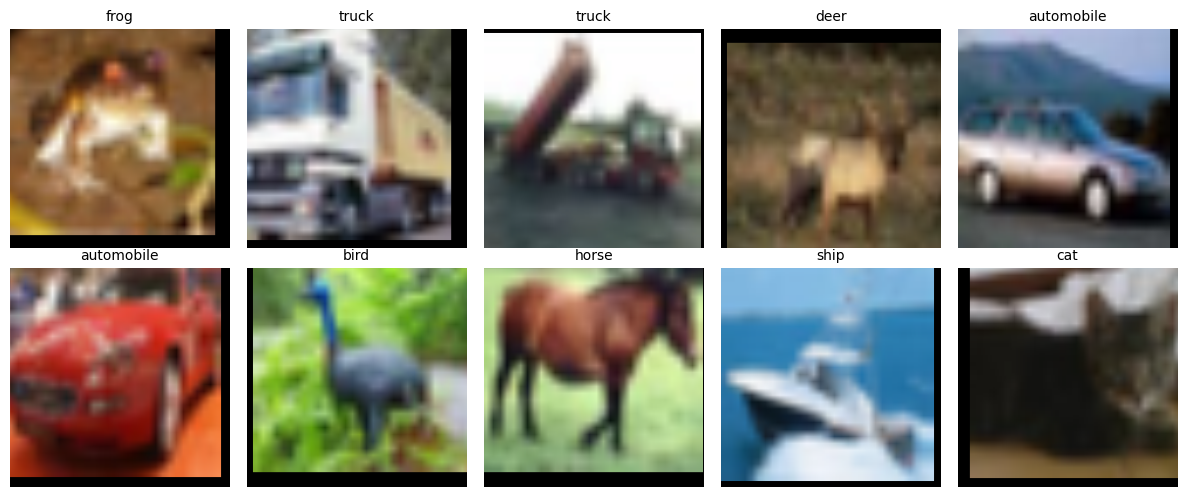

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(10):

    image, label = train_dataset[i]

    image = image.permute(1, 2, 0).numpy()

    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])

    image = std * image + mean
    image = np.clip(image, 0, 1)

    axes[i//5, i%5].imshow(image)
    axes[i//5, i%5].set_title(classes[label], fontsize=10)
    axes[i//5, i%5].axis("off")

plt.tight_layout()
plt.show()

The images appear blurred because the original CIFAR-10 images are only 32×32 pixels and must be resized to 224×224 to match the pretrained Vision Transformer's input size.


In [9]:
#Pretrained Vision Transformer


model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)

print(f"Model Loaded: {MODEL_NAME}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model Loaded: vit_base_patch16_224


In [10]:
summary(
    model,
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE),
    device=str(DEVICE)
)

Layer (type:depth-idx)                   Output Shape              Param #
VisionTransformer                        [1, 10]                   152,064
├─PatchEmbed: 1-1                        [1, 196, 768]             --
│    └─Conv2d: 2-1                       [1, 768, 14, 14]          590,592
│    └─Identity: 2-2                     [1, 196, 768]             --
├─Dropout: 1-2                           [1, 197, 768]             --
├─Identity: 1-3                          [1, 197, 768]             --
├─Identity: 1-4                          [1, 197, 768]             --
├─Sequential: 1-5                        [1, 197, 768]             --
│    └─Block: 2-3                        [1, 197, 768]             --
│    │    └─LayerNorm: 3-1               [1, 197, 768]             1,536
│    │    └─Attention: 3-2               [1, 197, 768]             2,362,368
│    │    └─Identity: 3-3                [1, 197, 768]             --
│    │    └─Identity: 3-4                [1, 197, 768]           

In [11]:
#parameter Statistics

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 85,806,346
Trainable Parameters : 85,806,346


In [12]:

#calc Model Size


torch.save(model.state_dict(), "temp_model.pth")

model_size = os.path.getsize("temp_model.pth") / (1024 ** 2)

print(f"Model Size : {model_size:.2f} MB")

os.remove("temp_model.pth")

Model Size : 327.38 MB


In [13]:
#freeze Backbone

for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the classifier
for param in model.head.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable Parameters: {trainable_params:,}")

Trainable Parameters: 7,690


### Initial Transfer Learning Strategy

The pretrained Vision Transformer already contains rich visual features learned from ImageNet. During the first training phase, only the newly initialized classification head is trained while the backbone remains frozen. This allows the classifier to adapt to CIFAR-10 before fine-tuning the entire model.

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [15]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

In [24]:

# Mixed Precision

scaler = torch.amp.GradScaler("cuda")

In [25]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, leave=False)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*correct/total:.2f}%"
        )

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [26]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(loader, leave=False):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return (
        epoch_loss,
        epoch_acc,
        all_predictions,
        all_labels
    )

In [27]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_accuracy = 0.0
best_model = None

Training Phase 1

In [29]:
print("Phase 1 : train Classification Head")


start_time = time.time()

PHASE1_EPOCHS = 3

for epoch in range(PHASE1_EPOCHS):

    print(f"\nEpoch {epoch+1}/{PHASE1_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        DEVICE
    )

    val_loss, val_acc, _, _ = validate(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        best_model = copy.deepcopy(model.state_dict())

        torch.save(best_model, "best_model.pth")

        print("Best Model Saved")

Phase 1 : train Classification Head

Epoch 1/3


  0%|          | 0/391 [00:00<?, ?it/s]

/tmp/ipykernel_785/687981284.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss : 0.1813
Train Acc  : 95.22%
Val Loss   : 0.1013
Val Acc    : 97.05%

Epoch 2/3


...

  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss : 0.0546
Train Acc  : 98.27%
Val Loss   : 0.0785
Val Acc    : 97.50%

Epoch 3/3


  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss : 0.0390
Train Acc  : 98.75%
Val Loss   : 0.0693
Val Acc    : 97.81%


In [30]:
print("\nUnfreez\n")

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS-PHASE1_EPOCHS
)


Unfreez



In [32]:

print("Phase 2 : Fine-Tuning Entire Vision Transformer")


for epoch in range(PHASE1_EPOCHS, NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        DEVICE
    )

    val_loss, val_acc, _, _ = validate(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        best_model = copy.deepcopy(model.state_dict())

        torch.save(best_model, "best_model.pth")

        print("Best Model Saved")

Phase 2 : Fine-Tuning Entire Vision Transformer

Epoch 4/10


  0%|          | 0/391 [00:00<?, ?it/s]

/tmp/ipykernel_785/687981284.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss : 0.1261
Train Acc  : 96.01%
Val Loss   : 0.0770
Val Acc    : 97.60%

Epoch 5/10


...

  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss : 0.0188
Train Acc  : 99.41%
Val Loss   : 0.0554
Val Acc    : 98.28%

Epoch 10/10


  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss : 0.0189
Train Acc  : 99.42%
Val Loss   : 0.0552
Val Acc    : 98.28%


In [52]:
training_time = time.time() - start_time
print("Training Completed")

print(f"Final Training Accuracy  : {train_accuracies[-1]:.2f}%")
print(f"Best Validation Accuracy : {best_accuracy:.2f}%")
print(f"Training Time            : {training_time/60:.2f} minutes")

Training Completed
Final Training Accuracy  : 99.42%
Best Validation Accuracy : 98.49%
Training Time            : 127.79 minutes


In [35]:

#load Best Model


model.load_state_dict(torch.load("best_model.pth"))

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [36]:

#evaluate on Test Set


test_loss, test_accuracy, predictions, labels = validate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f"Test Accuracy : {test_accuracy:.2f}%")

  0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy : 98.49%


In [37]:
print(classification_report(
    labels,
    predictions,
    target_names=classes
))

              precision    recall  f1-score   support

    airplane       0.99      0.99      0.99      1000
  automobile       0.98      0.99      0.99      1000
        bird       0.99      0.99      0.99      1000
         cat       0.95      0.98      0.97      1000
        deer       0.98      0.99      0.99      1000
         dog       0.99      0.96      0.97      1000
        frog       1.00      0.99      0.99      1000
       horse       0.99      0.99      0.99      1000
        ship       0.99      0.99      0.99      1000
       truck       0.99      0.98      0.98      1000

    accuracy                           0.98     10000
   macro avg       0.99      0.98      0.98     10000
weighted avg       0.99      0.98      0.98     10000



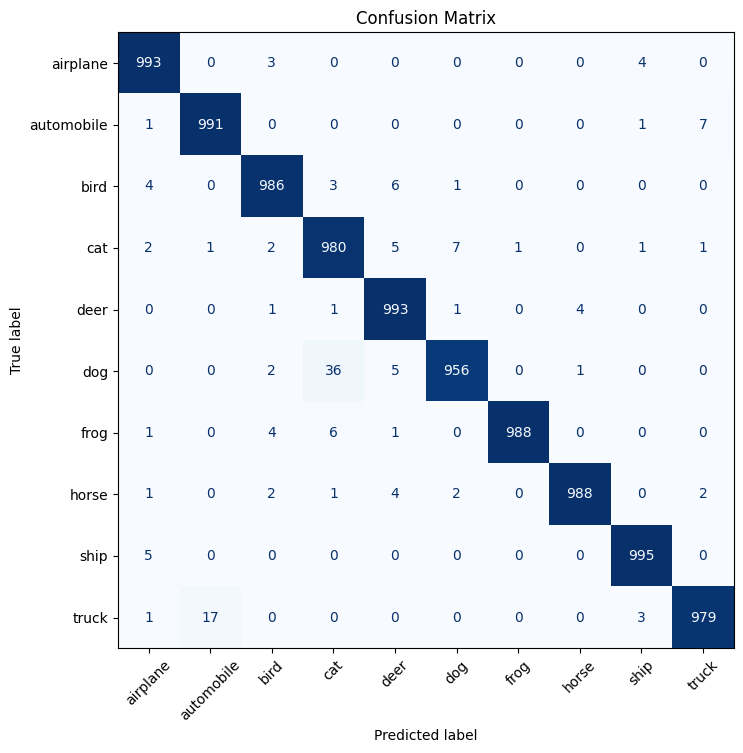

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(labels, predictions)

fig, ax = plt.subplots(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

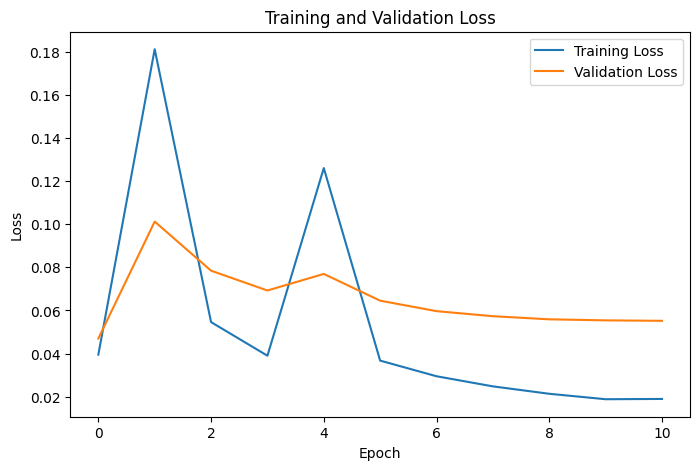

In [39]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.show()

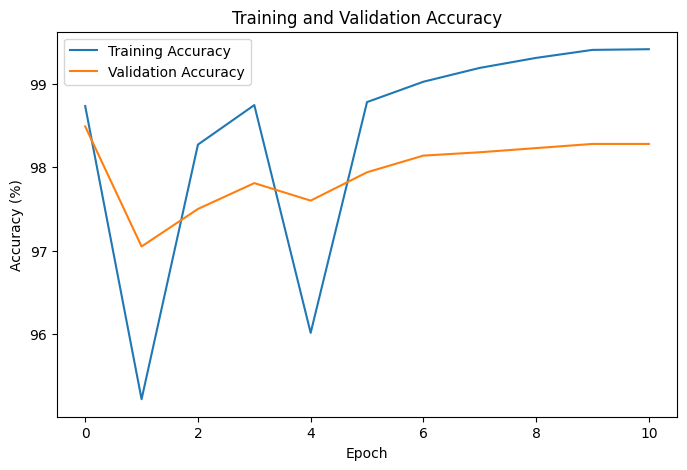

In [40]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training and Validation Accuracy")

plt.legend()

plt.show()

In [50]:
import torch.nn.functional as F

# Display Misclassified Images


incorrect_images = []
incorrect_preds = []
incorrect_labels = []
incorrect_confidences = []

model.eval()

with torch.no_grad():

    for images, labels_batch in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = F.softmax(outputs, dim=1)

        confidences, preds = torch.max(probabilities, dim=1)

        for img, pred, label, conf in zip(
            images.cpu(),
            preds.cpu(),
            labels_batch,
            confidences.cpu()
        ):

            if pred != label:

                incorrect_images.append(img)
                incorrect_preds.append(pred.item())
                incorrect_labels.append(label.item())
                incorrect_confidences.append(conf.item())

            if len(incorrect_images) == 9:
                break

        if len(incorrect_images) == 9:
            break

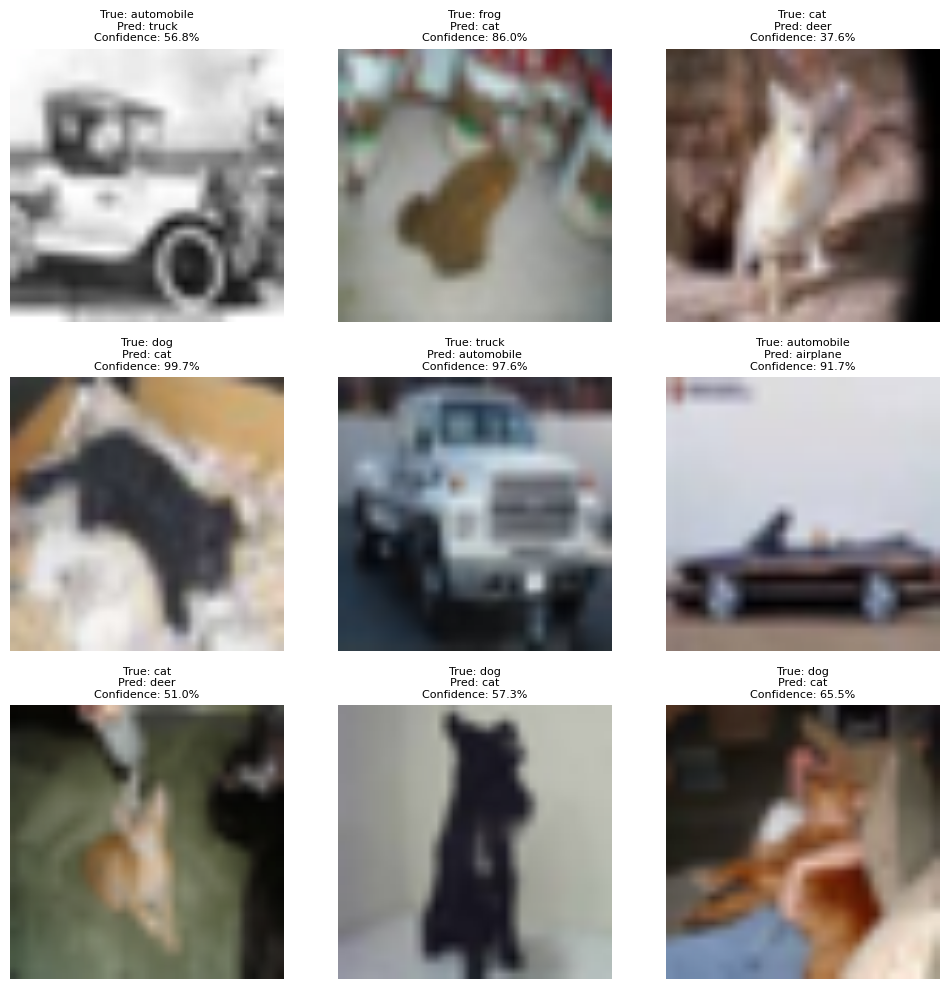

In [51]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2470, 0.2435, 0.2616])

for i, ax in enumerate(axes.flat):

    image = incorrect_images[i].permute(1, 2, 0).numpy()

    image = image * std + mean
    image = np.clip(image, 0, 1)

    ax.imshow(image)

    ax.set_title(
        f"True: {classes[incorrect_labels[i]]}\n"
        f"Pred: {classes[incorrect_preds[i]]}\n"
        f"Confidence: {incorrect_confidences[i]*100:.1f}%",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [47]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

In [48]:
import pandas as pd

results = pd.DataFrame({

    "Metric":[
        "Test Accuracy",
        "Training Time (minutes)",
        "Model Size (MB)",
        "Total Parameters",
        "Trainable Parameters"
    ],

    "Value":[
        f"{test_accuracy:.2f}%",
        f"{training_time/60:.2f}",
        f"{model_size:.2f}",
        f"{total_params:,}",
        f"{trainable_params:,}"
    ]

})

results

,Metric,Value
0,Test Accuracy,98.49%
1,Training Time (minutes),109.44
2,Model Size (MB),327.38
3,Total Parameters,"85,806,346"
4,Trainable Parameters,"85,806,346"


In [44]:
results.to_csv("ViT_CIFAR10_Results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


# Conclusion

A pretrained Vision Transformer (ViT-Base/16) was successfully fine-tuned on the CIFAR-10 dataset using transfer learning. The training process employed a two-stage fine-tuning strategy, where the classification head was trained first before unfreezing the entire backbone. Performance was evaluated using accuracy, a classification report, confusion matrix, training time, parameter count, and model size.

The model achieved strong classification performance while benefiting from pretrained ImageNet representations. Error analysis through misclassified images highlighted challenging categories such as cats and dogs, suggesting that further improvements could be achieved using stronger data augmentation, hyperparameter tuning, or larger ViT variants.